Imports data from TN Julia simulation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from tqdm.auto import tqdm
import os
import sys
from math import comb
from functools import partial

In [3]:
sys.path.append(os.path.abspath('../../src'))

In [4]:
from majo_gp import MajoQuantumKernel, derivative_gp_mean

### Specifcation of the Majorana system (and Majorana basis)

In [5]:
n = 55
STATE_PREP = "OAT"
#STATE_PREP = "TAT"

In [6]:
# Load all data:
sub_dir = f"{n}q"
O = np.load(f"../data/{sub_dir}/coeffs.npy")
print(f"Loaded O with norm {np.linalg.norm(O)}")
feature_vecs = np.load(f"../data/{sub_dir}/feat_vec.npy")
outputs = np.load(f"../data/{sub_dir}/outputs.npy")
ts = np.load(f"../data/{sub_dir}/t_list.npy")
thetas = np.load(f"../data/{sub_dir}/theta_list.npy")

Loaded O with norm 7.3484692283495345


In [7]:
n_skip = 1
n_skip_first = 0
n_skip_last = len(ts)
ts = ts[n_skip_first:n_skip_last:n_skip]
outputs = outputs[n_skip_first:n_skip_last:n_skip]
feature_vecs = feature_vecs[n_skip_first:n_skip_last:n_skip]

In [8]:
t_min, t_max = np.pi/8, 2*np.pi - np.pi/8
domain_mask = (t_min <= ts) & (ts <= t_max)
ts = ts[domain_mask]
outputs = outputs[domain_mask]
feature_vecs = feature_vecs[domain_mask]

In [9]:
# Infer the majorana system:
d = 2*n
# number of majoranas in the observable
for m in range(d):
    if comb(d, m) == feature_vecs.shape[-1]:
        break
print(f"Module B_{m}")
num_data_points = len(outputs)
n_params = ts.shape[-1] if ts.ndim > 1 else 1

Module B_2


## Simplified BO of derivative 
***Here we use the fact that at theta=0, the observable commutes with the initial state, i.e., constant observation. Hence, equivalent to just maximize directly for small pertubation delta_theta under finite forward/backward differences approximation. Hence, no explicit derivative of GP needed.***

In [10]:
# Fix thetas:
theta_idx = len(thetas) // 2 + 5
theta_fixed_idx = len(thetas) // 2
delta_theta = np.abs(thetas[theta_idx] - thetas[theta_fixed_idx])
print(f"delta_theta = {delta_theta}, at {thetas[theta_idx]} (index {theta_idx})")

delta_theta = 0.05, at 0.05 (index 25)


In [11]:
orig_2d_outputs = np.load(f"../data/{sub_dir}/outputs.npy")[n_skip_first:n_skip_last:n_skip][domain_mask]
outputs = orig_2d_outputs[:, theta_idx]
d_outputs = outputs
print("Outputs shape:", outputs.shape)

Outputs shape: (875,)


# Bayesian optimization

In [12]:
# Determine maximizing t brute force:
opt_idx = np.argmax(np.abs(d_outputs))
opt_t = ts[opt_idx]
opt_val = d_outputs[opt_idx]
print(f"Optimum at {opt_t}, {opt_val} (index {opt_idx}) at resolution {np.max(ts) - np.min(ts)}/{len(ts)}")

Optimum at 3.2861059156549235, 0.5058268719227916 (index 460) at resolution 5.491503958474958/875


  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 1000x480 with 0 Axes>

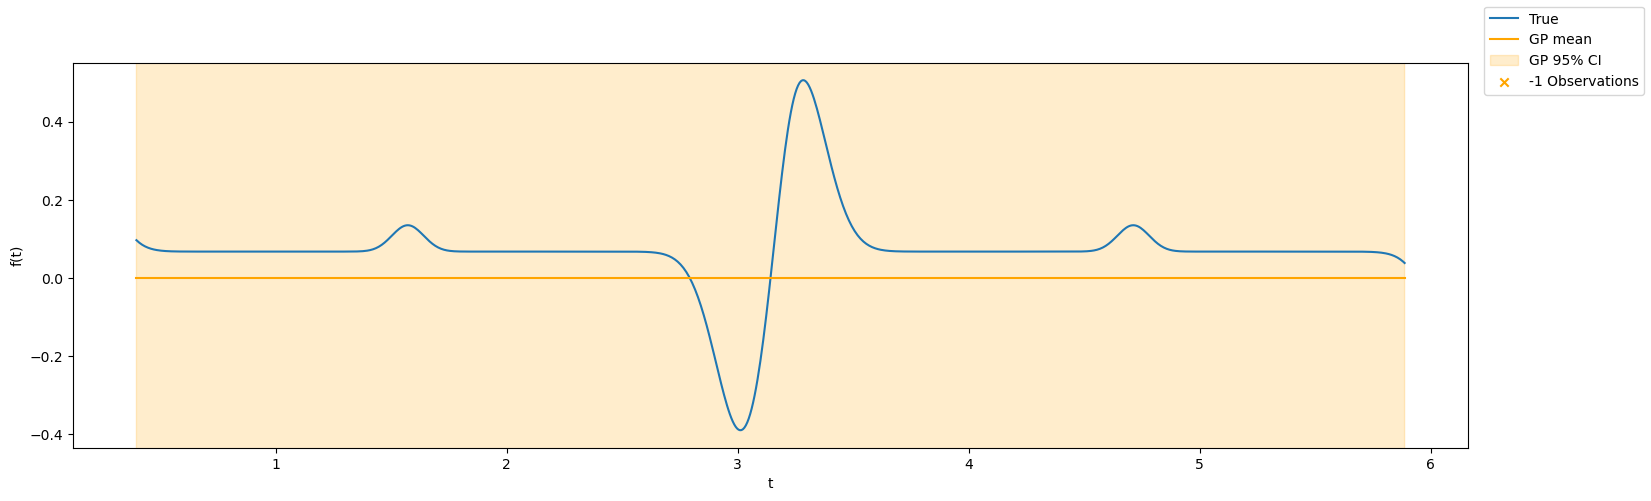

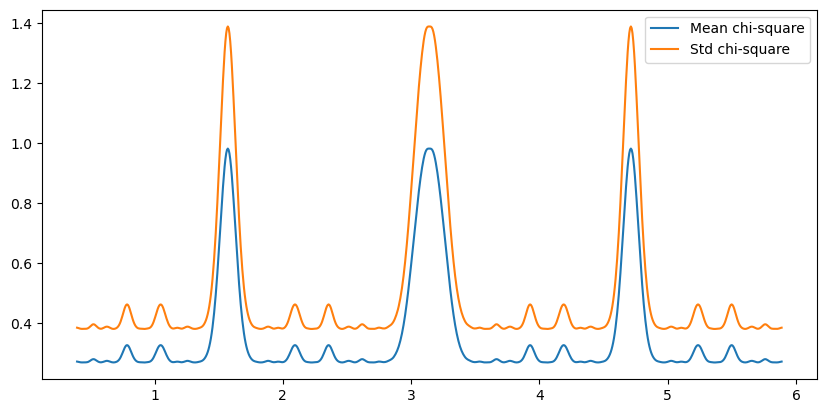

<Figure size 1000x480 with 0 Axes>

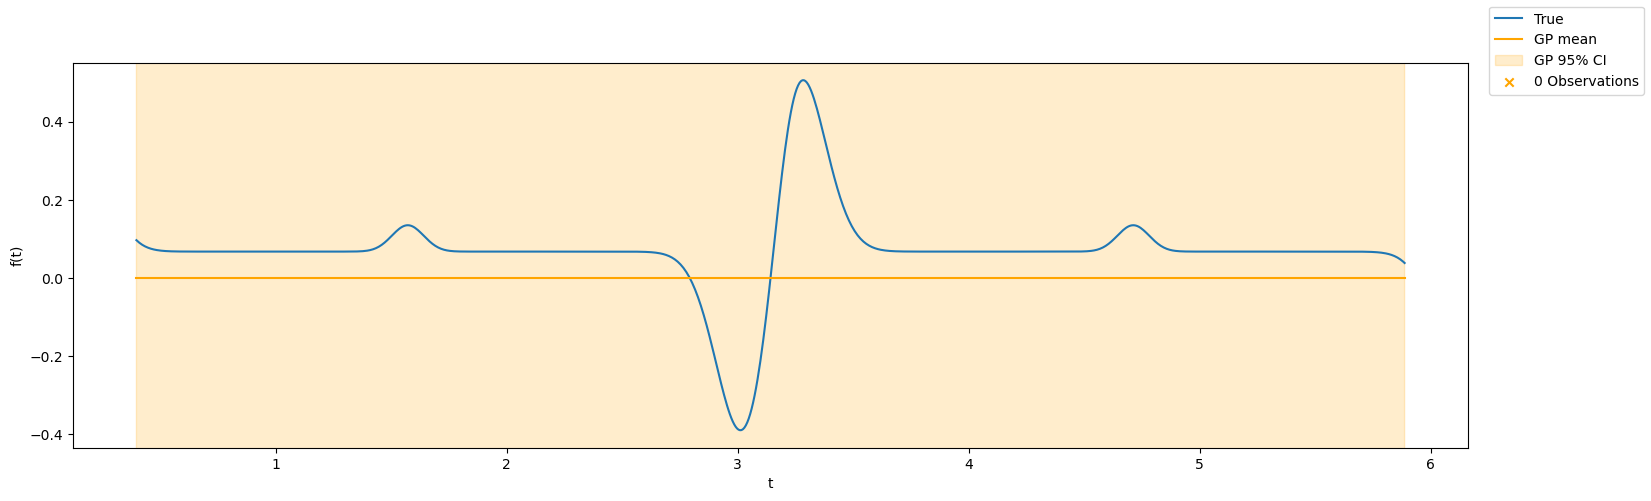

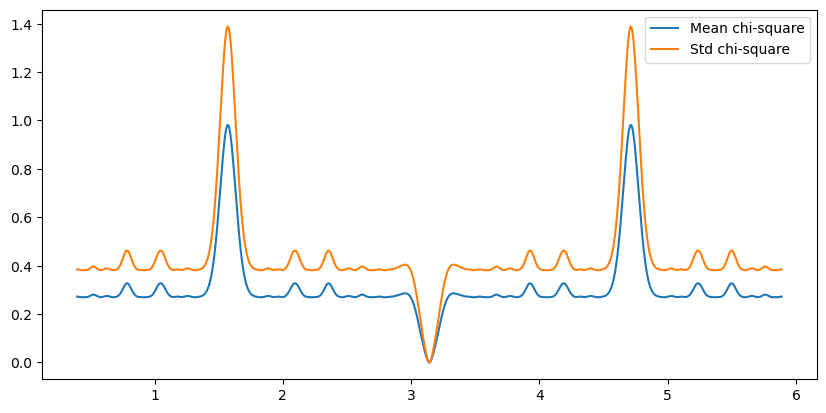

<Figure size 1000x480 with 0 Axes>

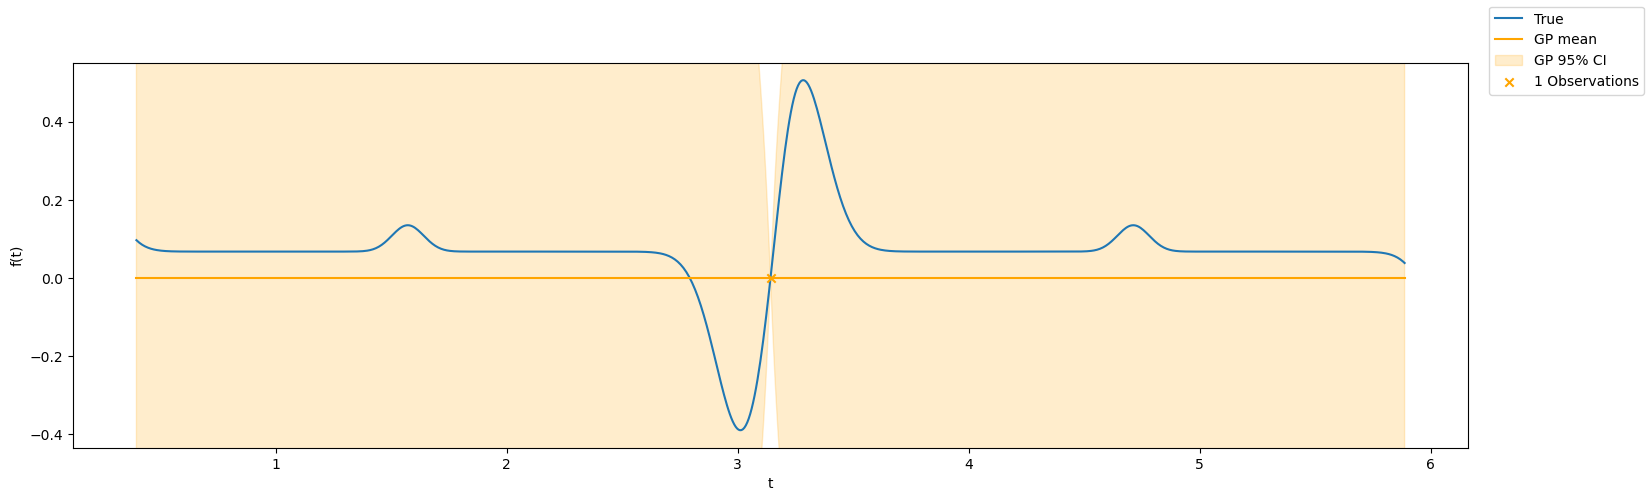

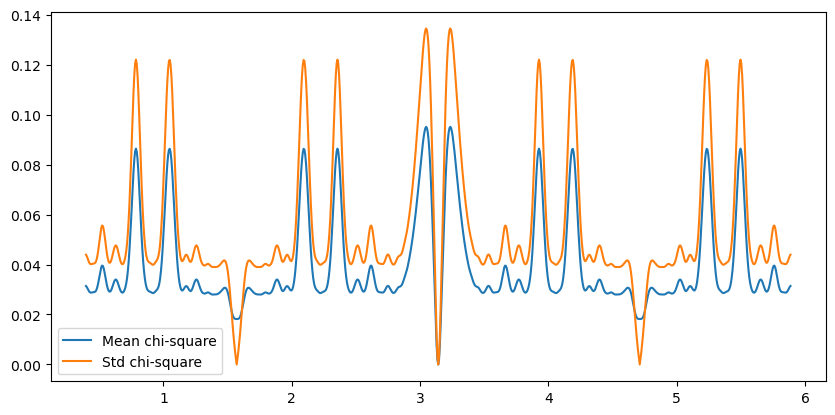

<Figure size 1000x480 with 0 Axes>

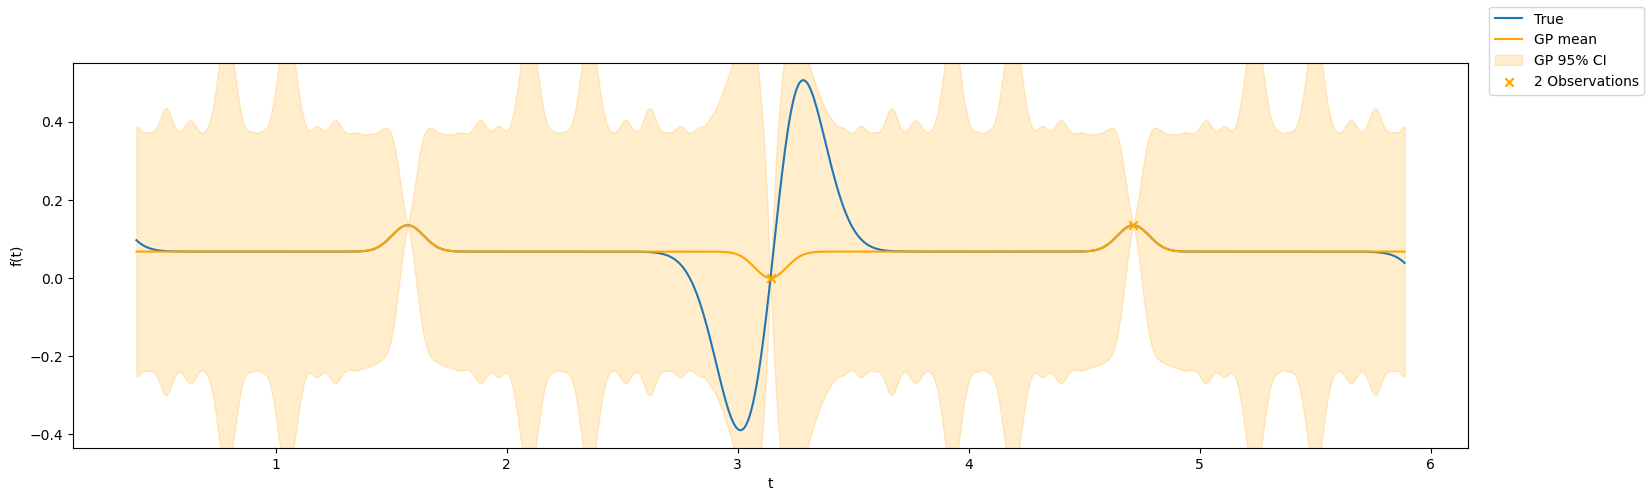

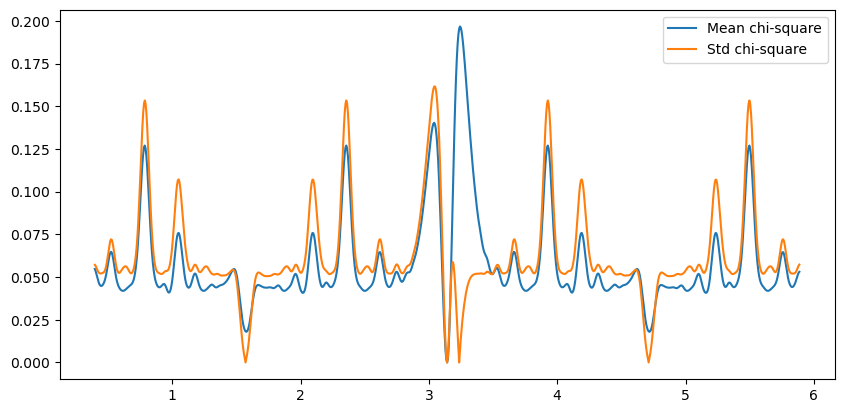

<Figure size 1000x480 with 0 Axes>

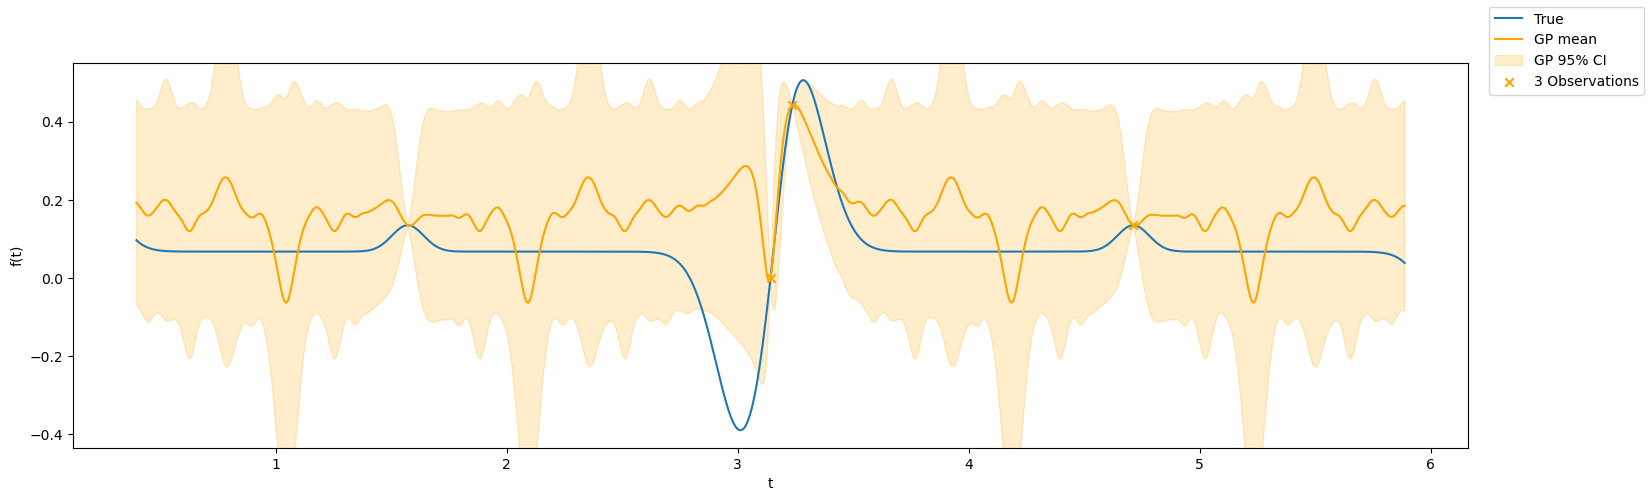

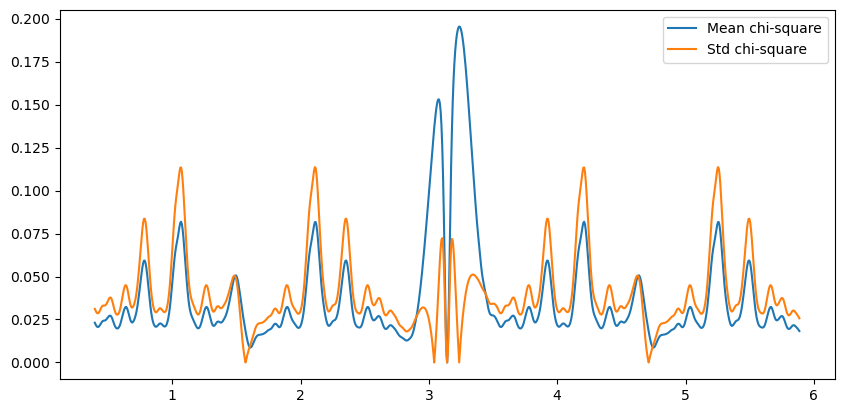

<Figure size 1000x480 with 0 Axes>

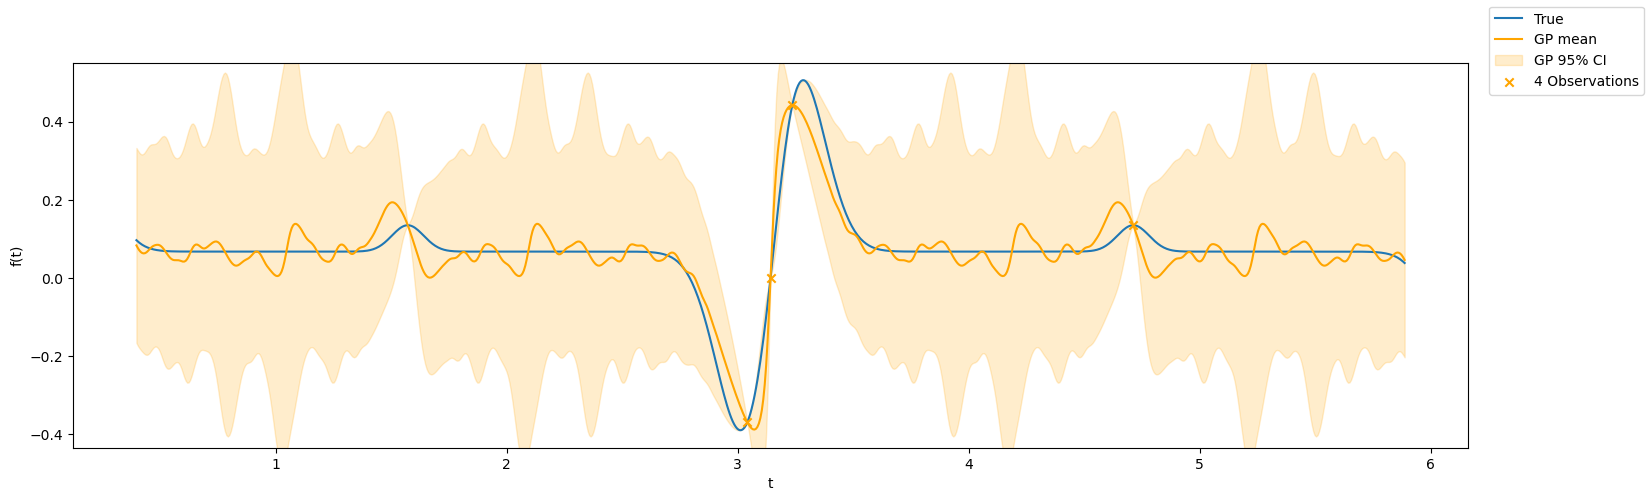

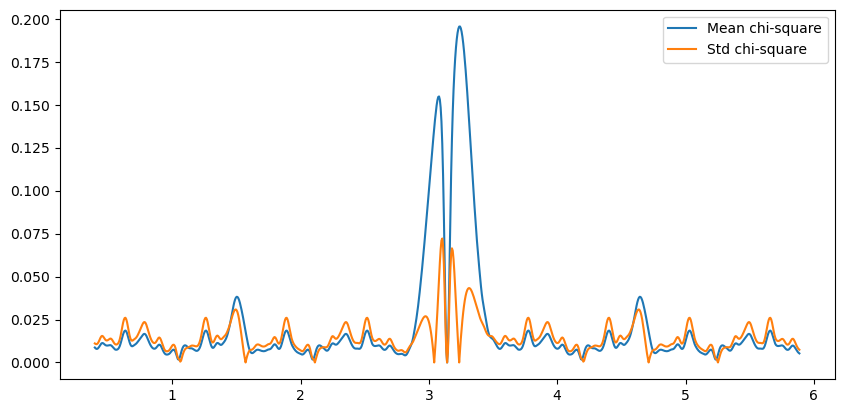

<Figure size 1000x480 with 0 Axes>

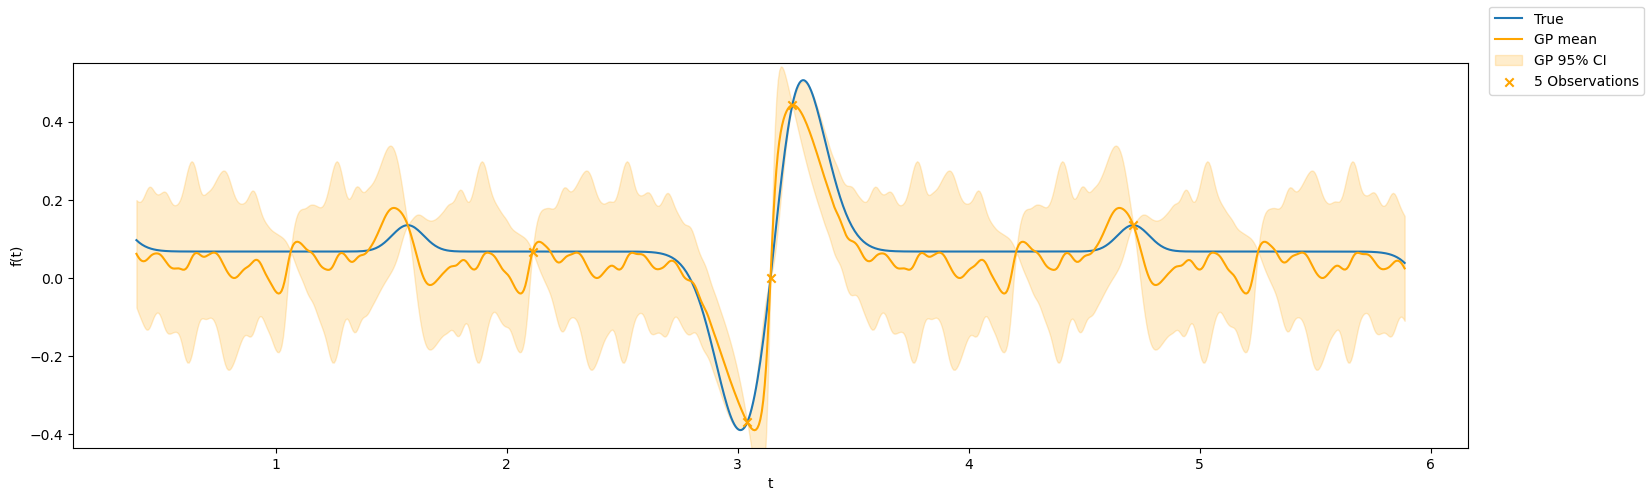

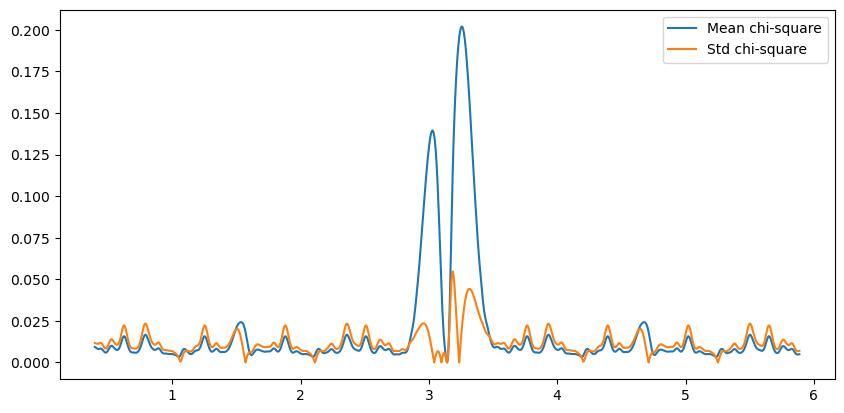

<Figure size 1000x480 with 0 Axes>

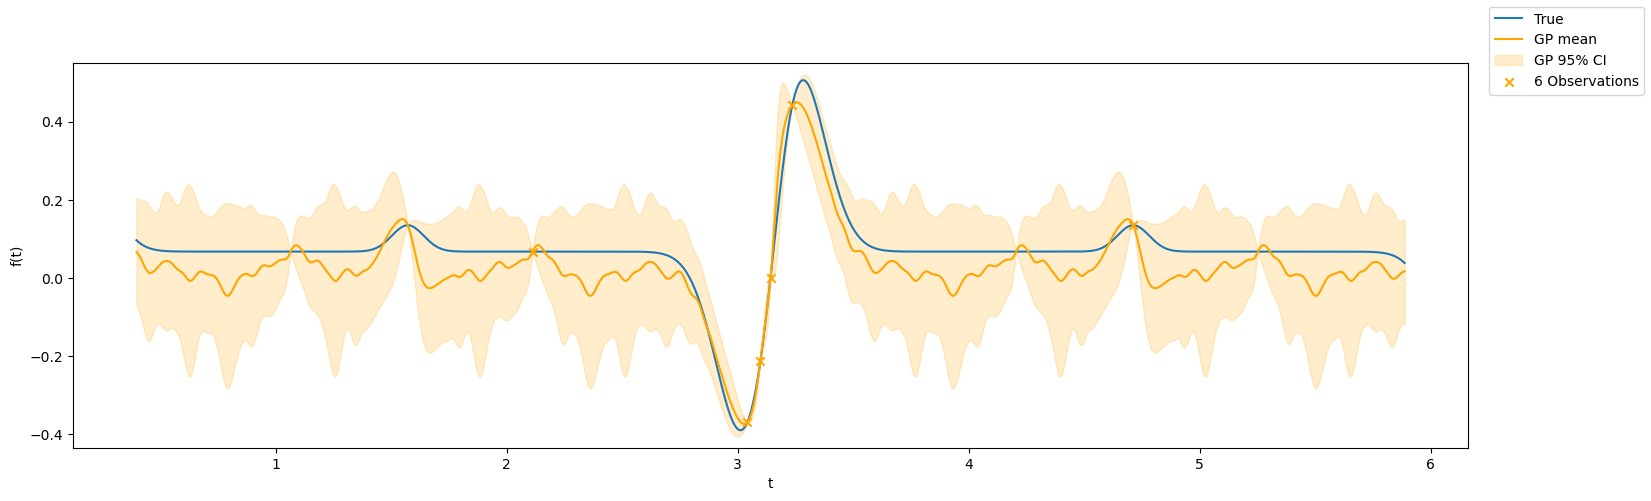

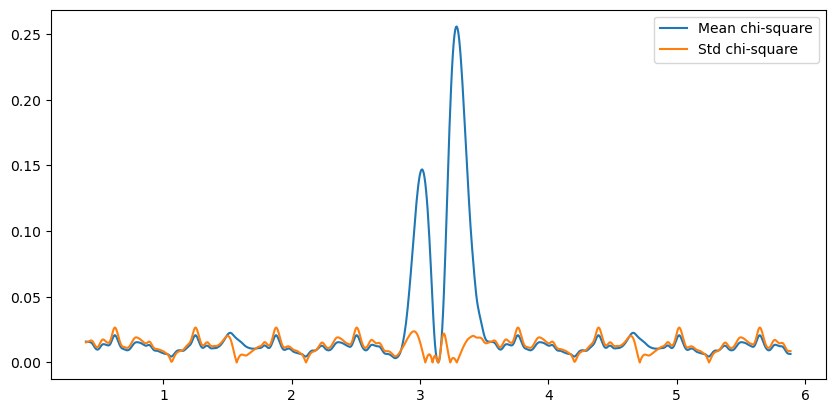

<Figure size 1000x480 with 0 Axes>

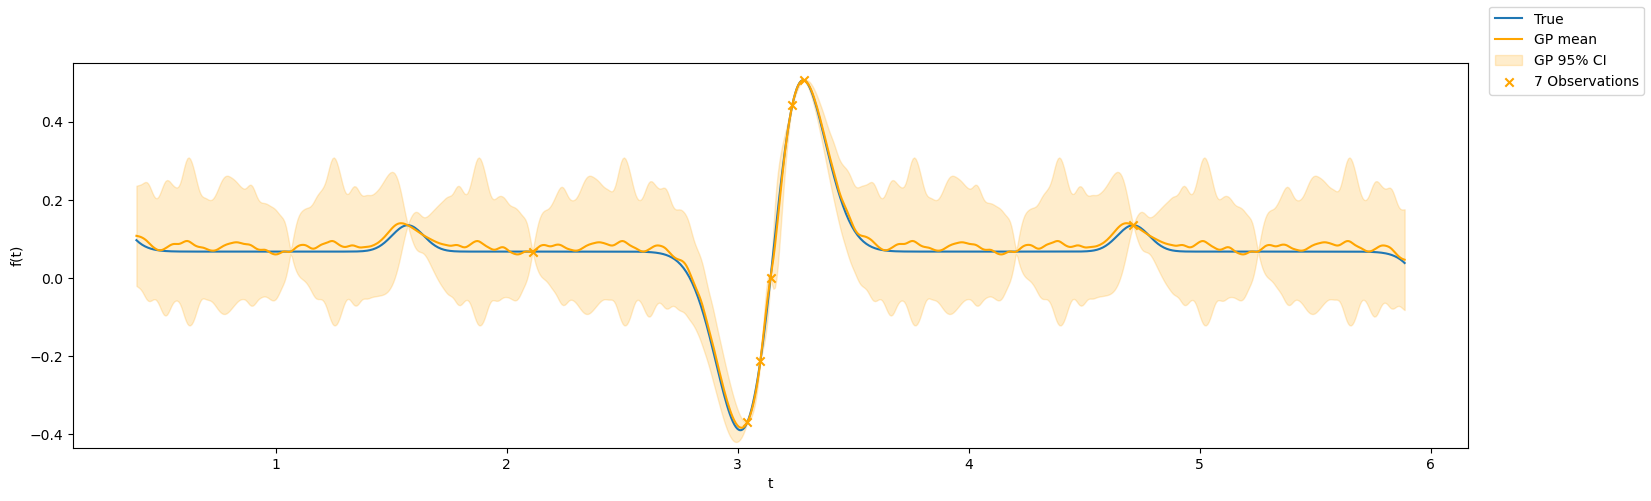

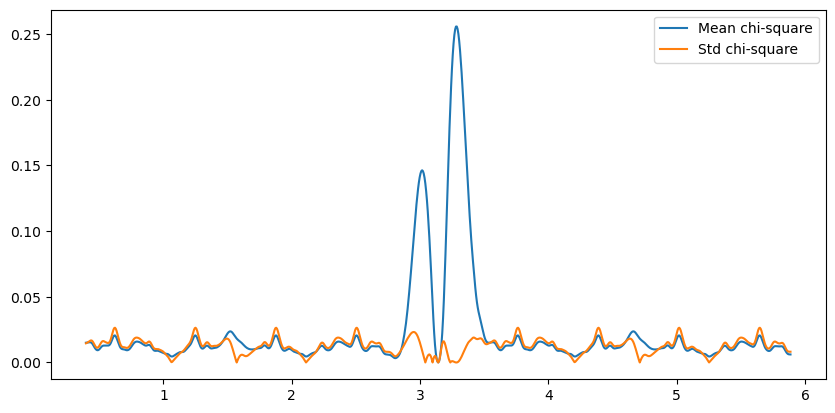

<Figure size 1000x480 with 0 Axes>

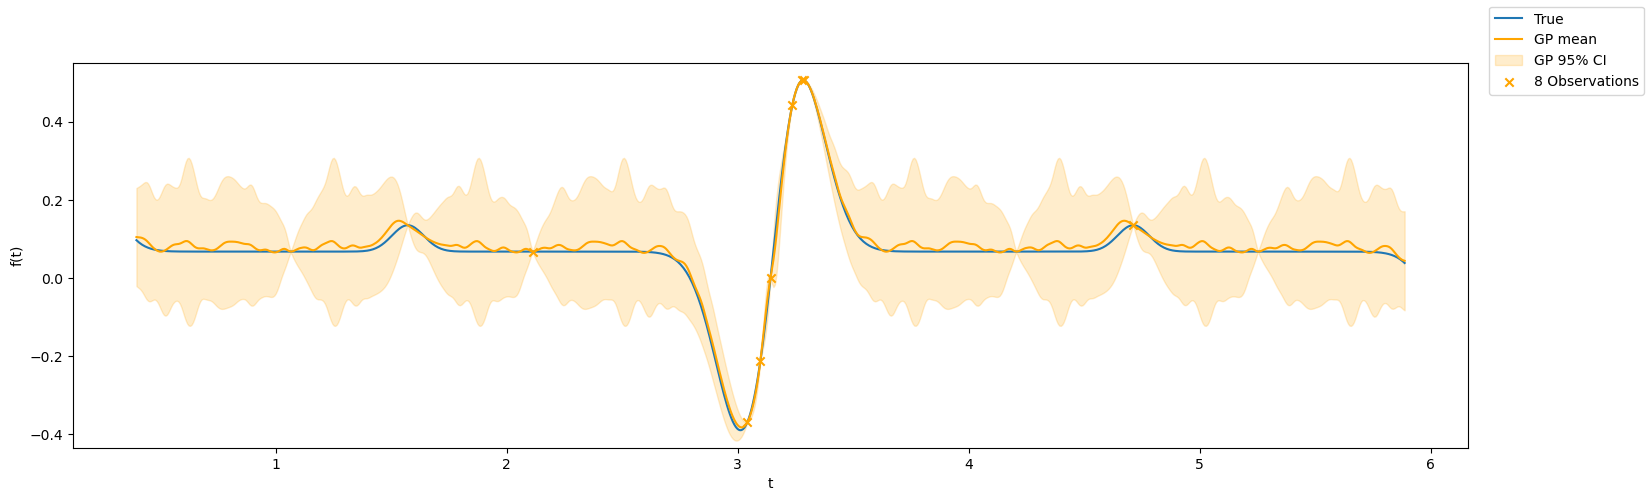

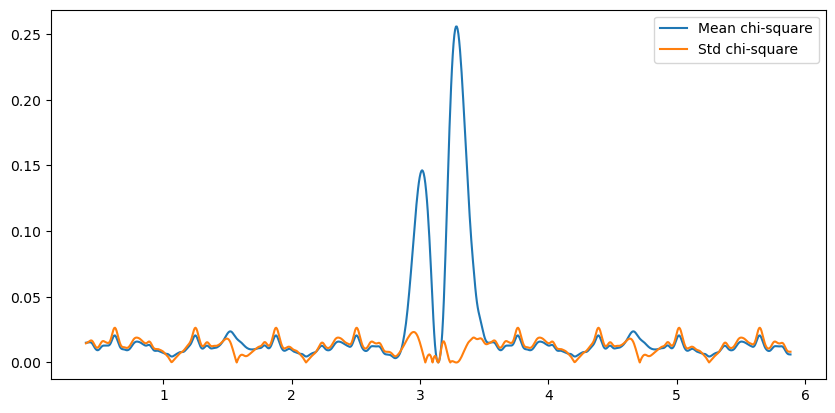

Predicted optimal point found: t=3.2861059156549235, f(t)=0.5058268719227916, idx=460 (after 7 observations). True optimum is at 3.2861059156549235, 0.5058268719227916, 437)


In [13]:
def d_fun_lookup(t):
    idx = np.argmin(np.abs(ts - t))
    return d_outputs[idx]

def fun_lookup(t):
    idx = np.argmin(np.abs(ts - t))
    return outputs[idx]

# fun and derivative lookup are the same because in simplified case, the output is already the derivative as forward diff approximation of interest 


plt.rcParams["figure.figsize"] = (10, 4.8)
max_calls = 10


kernel_func = MajoQuantumKernel(ts=ts, majo_observable=O, majo_feature_vecs=feature_vecs, n=n, m=m)
majo_gp = GaussianProcessRegressor(kernel=kernel_func)

def chi_square_ucb(X, model, kappa=1.96, callback=None):
    # Get the mean and standard deviation from the GP (Gaussian RVs)
    mean, std = model.predict(X, return_std=True)
    # Compute the chi-square acquisition function (lower confidence bound)
    mean_chi_square = mean**2 + std**2
    var_chi_square = 2 * (std**2) * (2*mean**2 + std**2)

    #print(f"Mean chi-square: {mean_chi_square},")
    #print(f"Variance chi-square: {var_chi_square}")
    plt.plot(X.flatten(), mean_chi_square, label='Mean chi-square')
    plt.plot(X.flatten(), np.sqrt(var_chi_square), label='Std chi-square')
    plt.legend()
    plt.show()

    if callback is not None:
        callback(mean_chi_square, var_chi_square, kappa)

    return (mean_chi_square + kappa * np.sqrt(var_chi_square))


logged_ts = []
logged_ts_indices = []
logged_obs = []
logged_d_ts = []
logged_d_obs_pred = []
logged_d_obs_std = []
logged_gp_preds = []
logged_gp_stds = []
logged_acquisition_vals = []


def acq_fn_callback(mean_chi_square, var_chi_square, kappa):
    packed = {
        "mean_chi_square": mean_chi_square,
        "var_chi_square": var_chi_square,
        "kappa": kappa
    }
    logged_acquisition_vals.append(packed)


acquisition_fn = partial(chi_square_ucb, kappa=1.96, callback=acq_fn_callback)

for i in (pbar := tqdm(range(max_calls))):

    dt = ts[1]-ts[0]

    # Plot the current state of the GP:
    plt.clf()
    fig, axs = plt.subplots(1, 1, figsize=(18, 5),)
    axs = np.atleast_1d(axs)  # Ensure axs is always an array, even if there's only one subplot
    axs[0].plot(ts, outputs, label='True')
    gp_pred, gp_std = majo_gp.predict(np.asarray(ts).reshape(-1, 1), return_std=True)
    logged_gp_preds.append(gp_pred)
    logged_gp_stds.append(gp_std)
    axs[0].plot(ts, gp_pred, label='GP mean', color='orange')
    # Also plot the 95% confidence interval:
    conf_int = 1.96*gp_std
    # get ylims before fill_between:
    ylims = axs[0].get_ylim()
    axs[0].fill_between(ts, gp_pred - conf_int, gp_pred + conf_int, alpha=0.2, label='GP 95% CI', color='orange')
    axs[0].set_ylim(*ylims)
    axs[0].scatter(logged_d_ts[:-1], logged_obs[:-1], marker='x', label=f'{len(logged_ts)-1} Observations', zorder=50, color='orange')


    # Next point to sample as vertical line:
    axs[0].set_xlabel('t')
    axs[0].set_ylabel('f(t)')
    # place legend outside the plot (right):
    fig.legend(loc='outside right upper')
    plt.show()

    if i > 0:  # skip fixed initial guess; use unconditioned GP for the first iteration
        # Refit the GP (refit)
        majo_gp.fit(np.asarray(logged_d_ts).reshape(-1, 1), logged_obs)

    acq_fn_vals_min = acquisition_fn(np.asarray(ts).reshape(-1, 1), majo_gp)

    while True:  # this code can be used to prevent querying the same point again
        #idx_next_max = np.argmax(acq_fn_vals_max)
        idx_next = np.argmax(acq_fn_vals_min)
        #idx_next = idx_next_min #if acq_fn_vals_max[idx_next_max] < acq_fn_vals_min[idx_next_min] else idx_next_max
        if True:#idx_next not in logged_ts_indices or len(logged_ts_indices) == len(acq_fn_vals_min):
            break
        else:
            # If we already sampled this point, try the next one
            acq_fn_vals_min[idx_next] = -np.inf  # Set this point to a very low value

    t_next = ts[idx_next]
    t_d_next = ts[idx_next]

    axs[0].axvline(t_next, color='red', linestyle='--', label='Next point to sample' if len(logged_ts) > 0 else 'Initial guess')

    # evaluate cost function:
    obs_next = fun_lookup(t_d_next)
    logged_ts.append(t_next)
    logged_d_ts.append(t_d_next)
    logged_ts_indices.append(idx_next)
    logged_obs.append(obs_next)
    logged_d_obs_pred.append(d_fun_lookup(t_next))
    
    # Update progress bar:
    pbar.set_description(f"Iteration {i+1}/{max_calls}, t={t_next:.2f}, f(t)={obs_next:.2f}")


# Report optimal point found:
opt_idx = np.argmax(np.abs(logged_d_obs_pred))
opt_t, opt_obs = logged_ts[opt_idx], logged_d_obs_pred[opt_idx]
t_idx = np.argmin(np.abs(ts - opt_t))
print(f"Predicted optimal point found: t={opt_t}, f(t)={opt_obs}, idx={t_idx} (after {opt_idx + 1} observations). True optimum is at {ts[np.argmax(np.abs(d_outputs))]}, {np.max(np.abs(d_outputs))}, {np.argmin(np.abs(d_outputs))})")

In [14]:
# Save to file (.npz)
base_dir = "../results"
os.makedirs(base_dir, exist_ok=True)
np.savez_compressed(os.path.join(base_dir, f"results_{n}q_simplified.npz"),
         logged_ts=logged_ts, logged_obs=logged_obs,
                    logged_d_obs_pred=logged_d_obs_pred, logged_d_obs_std=logged_d_obs_std,
                    logged_gp_preds=logged_gp_preds,
                    logged_gp_stds=logged_gp_stds,
                    opt_t=opt_t, opt_obs=opt_obs, opt_idx=opt_idx,
                    logged_acquisition_vals=logged_acquisition_vals,)